### Matplotlib Advanced Practice Test
Dataset: `../data/titanic.csv`

**Instructions:**
Write the exact Matplotlib/Seaborn implementations for each task. The instructions only state the final objective. No step-by-step guidance is provided. DO NOT use `pandas` internal plotting (e.g., `df.plot()`), stick to `matplotlib.pyplot` and `seaborn`.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('../data/titanic.csv')
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Task 1: Basic Pie Chart (Easy)
Create a Pie Chart showing the proportion of passengers from each `Embarked` port (C, Q, S). Display the percentages on the chart with one decimal place. Add a shadow and an appropriate title.

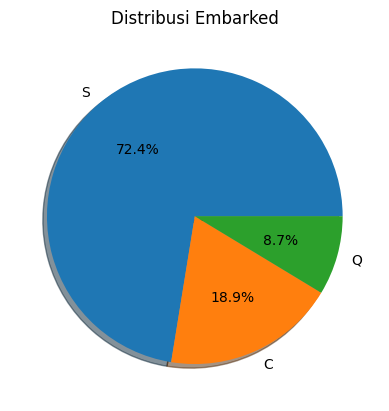

In [8]:
# Write your code here
plt.pie(df['Embarked'].value_counts().values, labels=df['Embarked'].value_counts().index, autopct='%1.1f%%', shadow=True)
plt.title('Distribusi Embarked')
plt.show()

#### Task 2: Histogram with Bins (Easy)
Plot a Histogram to see the distribution of the `Fare` column. Set the number of bins to 40 and the color to 'orange'. Add an edge color to make the bins stand out. Label the X-axis 'Ticket Fare' and the Y-axis 'Frequency'.

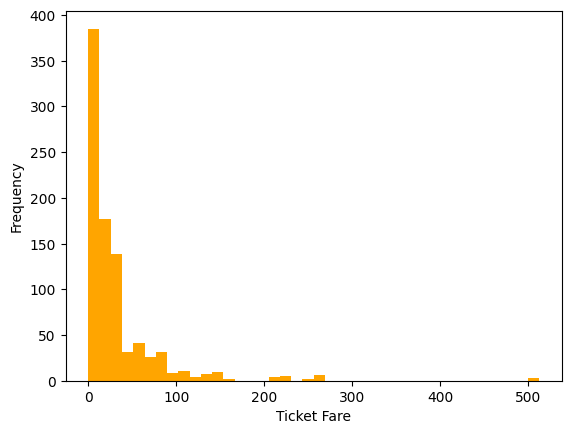

In [11]:
# Write your code here
plt.hist(df['Fare'], bins=40, color='orange')
plt.xlabel('Ticket Fare')
plt.ylabel('Frequency')
plt.show()

#### Task 3: Value Count Bar Chart (Medium)
Use a Matplotlib Bar Chart to show the total number of passengers in each `Pclass` (1, 2, 3). Ensure the X-axis ticks exactly match the class numbers.

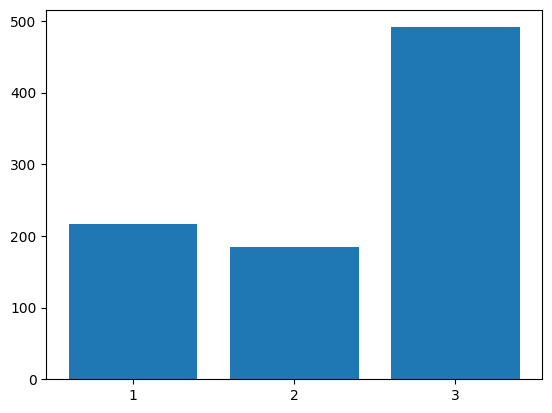

In [17]:
# Write your code here
labels, count = np.unique(df['Pclass'], return_counts=True)
plt.bar(labels,count)
plt.xticks(labels, labels)
plt.show()

#### Task 4: Scatter Plot with Matplotlib (Medium)
Create a Scatter Plot to investigate the relationship between `Age` (X-axis) and `Fare` (Y-axis). Color the dots completely red and set their transparency (alpha) to 50% so overlapping points are visible.

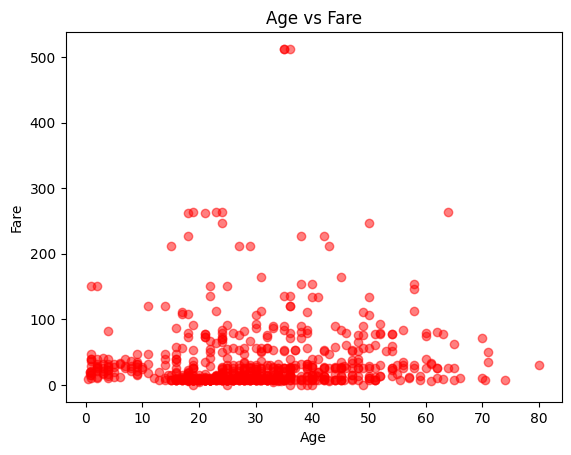

In [19]:
# Write your code here
plt.scatter(df['Age'], df['Fare'], color='r', alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
plt.show()

#### Task 5: Plotting Lines (Medium)
Calculate the **median Age** for each distinct `Pclass`. Plot these 3 values as a Line Chart using Matplotlib. Use a dashed line style ('--') and add circular markers at each point.

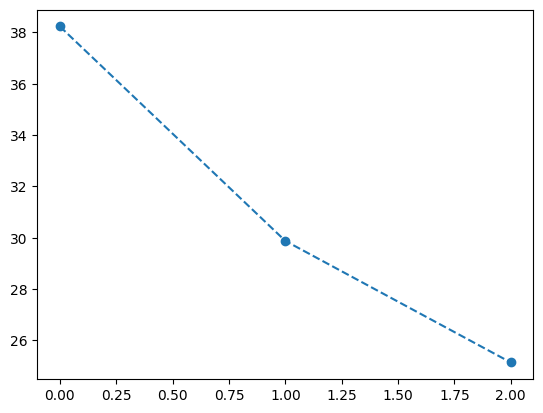

In [35]:
# Write your code here
# mean_p1 = df[df['Pclass']==1]['Age'].mean()
# mean_p2 = df[df['Pclass']==2]['Age'].mean()
# mean_p3 = df[df['Pclass']==3]['Age'].mean()

plt.plot(df.groupby('Pclass')['Age'].mean().values, linestyle='--', marker='o')
plt.show()

#### Task 6: Boxplot Grouping (Medium-Hard)
Create a Boxplot showing the distribution of `Age` grouped by `Survived` status (one boxplot for Survived=0, one for Survived=1 side-by-side). Drop missing ages before plotting. Add grid lines along the Y-axis.

C:\Users\Dindin\AppData\Local\Temp\ipykernel_22400\1658719829.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Survived']==0]['Age'].dropna().values, df[df['Survived']==1]['Age'].dropna().values], labels=['die', 'survived'], patch_artist=True)


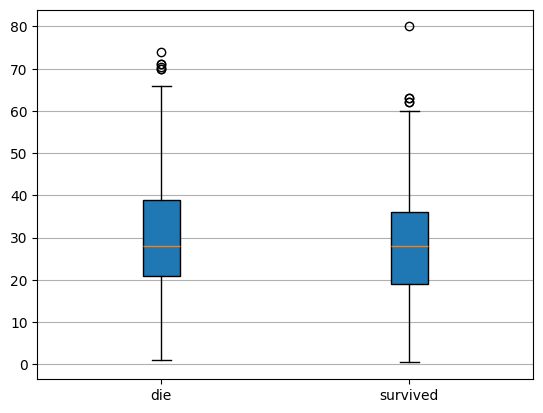

In [49]:
# Write your code here
plt.boxplot([df[df['Survived']==0]['Age'].dropna().values, df[df['Survived']==1]['Age'].dropna().values], labels=['die', 'survived'], patch_artist=True)
plt.grid(True, axis='y')
plt.show()

#### Task 7: Subplots Generation (Hard)
Create a figure with 2 Subplots arranged horizontally (1 row, 2 columns).
- On the LEFT axes: Plot a Matplotlib Bar Chart of `Sex` value counts.
- On the RIGHT axes: Plot a Seaborn `countplot` showing the count of `Survived` categorized by `Pclass` (using the `hue` argument).
Ensure both subplots have appropriate titles.

In [59]:
sns.countplot?

Signature:
sns.countplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    hue_norm=None,
    stat='count',
    width=0.8,
    dodge='auto',
    gap=0,
    log_scale=None,
    native_scale=False,
    formatter=None,
    legend='auto',
    ax=None,
    **kwargs,
)
Docstring:
Show the counts of observations in each categorical bin using bars.

A count plot can be thought of as a histogram across a categorical, instead
of quantitative, variable. The basic API and options are identical to those
for :func:`barplot`, so you can compare counts across nested variables.

Note that :func:`histplot` function offers similar functionality with additional
features (e.g. bar stacking), although its default behavior is somewhat different.

See the :ref:`tutorial <categorical_tutorial>` for more information.

.. note::
    By default, this function treats one of the 

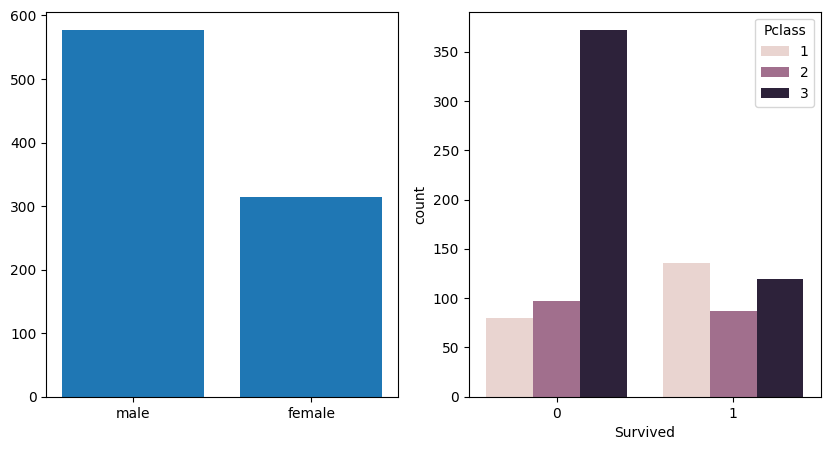

In [63]:
# Write your code here
fig, axe = plt.subplots(1,2, figsize=(10,5))
axe[0].bar(df['Sex'].value_counts().index, df['Sex'].value_counts().values)
axe[1] = sns.countplot(df, x='Survived', hue='Pclass')
plt.show()

#### Task 8: Seaborn Correlation Heatmap & Savefig (Competition Style - Hard)
Filter the dataframe to include ONLY the columns: `Survived`, `Pclass`, `Age`, `Fare`. 
Calculate their correlation matrix.
Plot a Seaborn Heatmap of this matrix. Annotate the squares with the numeric values. Use the 'coolwarm' color map.
Before calling `plt.show()`, save the figure as `titanic_corr.png` with a DPI of 300 in the current folder.

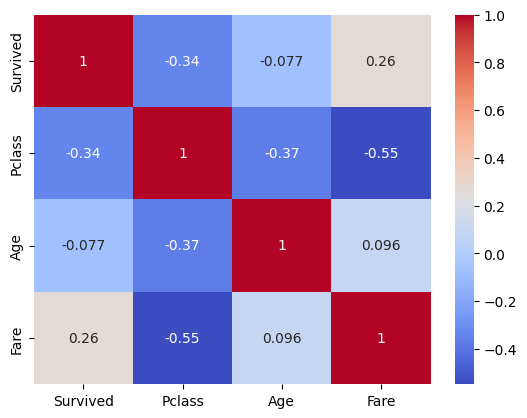

In [68]:
# Write your code here

sns.heatmap(df[['Survived', 'Pclass', 'Age', 'Fare']].corr(), annot=True, cmap='coolwarm')
plt.savefig('titanic_corr.png', dpi=300)
plt.show()